In [1]:
%load_ext autoreload
%autoreload 2

# Threshold Tuning: Multiclass Case

This notebook extends the [binary case](./binary_case.ipynb) to a **multiclass decision**, using `causalopt` with `mode="multiclass"`.

## The problem

A classifier assigns each customer to one of `K` actions by taking the **argmax of a score vector** — e.g. three offers with predicted probabilities `(p_1, p_2, p_3)`, and we give the customer the offer with the highest probability. That plain argmax is rarely the *business-optimal* rule: shifting the decision boundaries can raise the outcomes we care about.

Formally, instead of `T = argmax_k p_k`, we allow a **thresholded rule**

$$T = \arg\max_k \; (p_k - \tau_k),$$

and tune the threshold vector `τ` (one offset per class). With `τ = (1/K, …, 1/K)` we recover the plain argmax; moving `τ` moves the boundaries between classes.

## The idea

Each pairwise boundary between two classes is a **local discontinuity**: customers just on either side are nearly identical except for the action they receive. That is a regression-discontinuity setup, applied to every class boundary at once. `causalopt`:

1. selects a neighborhood around each pairwise boundary (bandwidth selection),
2. fits a local polynomial per class region and predicts each customer's outcome under *every* action,
3. sweeps a grid of candidate `τ` vectors and, for each, measures the change in outcomes vs. the current rule,
4. returns the **frontier** of `(τ → gain)` and the **welfare-optimal `τ` per outcome**.

## Scope of this notebook

We cover the **simplex case** (`probabilities=True`): the score columns are genuine class probabilities, so each row sums to 1 and lies in `[0, 1]`, and the tuned `τ` also lives on the simplex (`sum(τ) = 1`). We use `K = 3` so the decision regions can be drawn on a triangle.

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causalopt import causalopt
from causalopt.multiclass import decision_rule, generate_simulated_data, plot_simplex

logging.basicConfig(level=logging.INFO)

## 1. Simulate a 3-class dataset

We generate a synthetic example so the effects are known:

- Each customer has a **probability vector** `(Prob_1, Prob_2, Prob_3)` drawn from a Dirichlet distribution (so each row sums to 1 — a point on the simplex).
- The current rule uses `tau = (0.33, 0.33, 0.34)`, i.e. essentially plain argmax, to assign each customer a class `T`.
- Two outcomes are simulated:
  - `Y` — a **binary outcome** (e.g. whether the customer completes), whose probability depends on the assigned action and the score vector.
  - `R` — a **revenue-style outcome** (positive, right-skewed), which differs across actions.

Because the actions trade off `Y` against `R`, the threshold that is best for `Y` need not be best for `R` — the tuner surfaces that tension.

In [3]:
tau = np.array([0.33, 0.33, 1 - 0.66])  # current thresholds (sum to 1)

data = generate_simulated_data(
    n=3000,
    K=3,
    tau=tau,
    alpha_dirichlet=[5, 5, 5],  # vertex-heavy probabilities
    alpha_T={1: -1.0, 2: -0.3, 3: 0.6},  # action effects on the binary outcome
    beta=np.array([0.6, 0.3, 0.1]),
    sigma=1.0,
    seed=42,
    mu_R=5,
    delta_R=0.2,
    sigma_R=1.0,
    add_R=True,
)

data.head()

,Prob_1,Prob_2,Prob_3,T,Y,R
0,0.405087,0.304252,0.290660,1,0,0.000000
1,0.212295,0.456043,0.331661,2,0,0.000000
2,0.250401,0.399357,0.350243,2,1,105.993823
3,0.166436,0.285553,0.548011,3,1,28.049139
4,0.525036,0.256067,0.218897,1,0,0.000000


## 2. Inspect the data

Grouping by the assigned action `T` shows how many customers each action reaches and its average outcomes. This is the status-quo the tuner will try to improve on.

In [4]:
data.groupby("T").agg(
    row_count=("Y", "size"),
    mean_Y=("Y", "mean"),
    mean_R=("R", "mean"),
)

,row_count,mean_Y,mean_R
T,,,
1,1061,0.260132,64.542462
2,999,0.534535,57.625101
3,940,0.806383,46.222029


## 3. Current decision regions on the simplex

With `K = 3`, every probability vector is a point in a triangle (the 2-simplex). The current rule partitions that triangle into three regions — one per action. `plot_simplex` shades the regions implied by `tau` and overlays the customers, colored by their assigned action `T`.

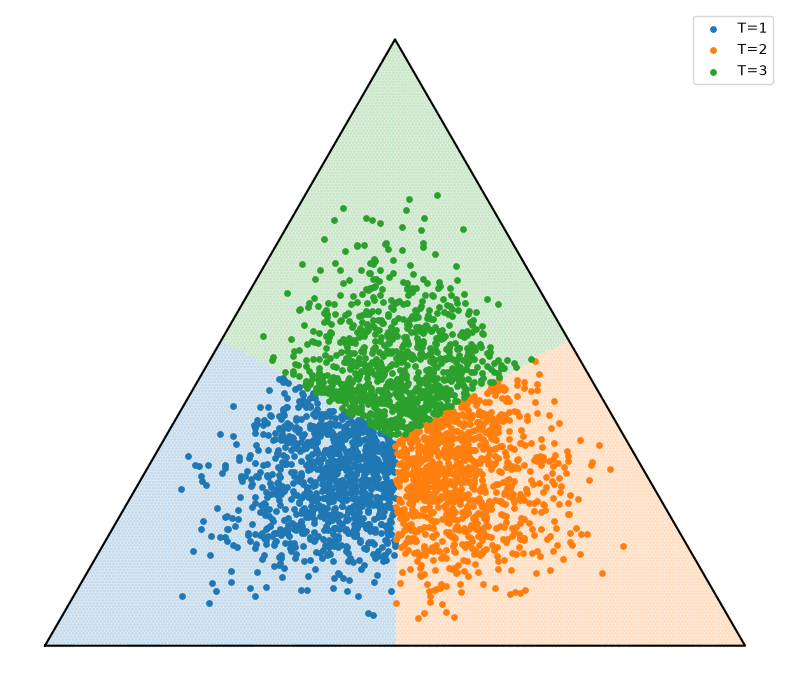

In [5]:
plot_simplex(data, tau)

## 4. Tune the thresholds with `causalopt`

We call the same unified entry point as the binary case, now with `mode="multiclass"`:

| Argument | Meaning |
| --- | --- |
| `df` | the DataFrame for the analysis |
| `outcomes` | the outcome column(s) to evaluate — here `["Y", "R"]` |
| `score_cols` | the `K` probability columns (the classifier's score vector) |
| `mode="multiclass"` | selects the multiclass tuner |
| `tau` | the current threshold vector (defaults to plain argmax, `1/K` each) |
| `probabilities=True` | inputs are on the simplex (the default); validated fail-fast |

The result is a single dictionary:

- `results["frontier"]` — every candidate `τ` with the mean/total change in each outcome vs. the current rule
- `results["optimum"]` — the welfare-optimal `τ` **per outcome**, plus what the other outcomes do at that `τ`
- `results["current"]` — the supplied `τ` (the zero-gain reference)
- `results["details"]` — the call parameters (kernel, budget, regime) **plus** the computed intermediates: `data_descriptives`, `prepared` (distances + current assignment `T`), `bandwidths`, `estimates` (per-class RD fits), `predictions` (counterfactual surfaces), and `curves` (grid-evaluated fitted curves with confidence bands per outcome/class/boundary)

> Note: with `B = 10_000` and `K = 3` this sweeps a 100×100 grid of candidate thresholds and fits local polynomials per region, so it takes a few seconds.

In [6]:
outcomes = ["Y", "R"]
score_cols = ["Prob_1", "Prob_2", "Prob_3"]

results = causalopt(
    data,
    outcomes,
    score_cols,
    mode="multiclass",
    tau=[0.33, 0.33, 0.34],
    probabilities=True,
)

results["mode"], results["current"]["tau"]

('multiclass', (0.33, 0.33, 0.34))

## 5. The tradeoff frontier

`results["frontier"]` has one row per candidate threshold vector `τ`, with:

- `tau_1, tau_2, tau_3` — the candidate thresholds (on the simplex, so they sum to 1)
- `mean_{outcome}` — the average per-customer change in that outcome vs. the current rule
- `total_{outcome}` — the summed change across all customers

Sorting by an outcome's `mean_` column shows which thresholds move that outcome the most. Below we peek at the top rows for `Y`.

In [7]:
frontier = results["frontier"]
frontier.sort_values("mean_Y", ascending=False).head()

,tau_1,tau_2,tau_3,mean_Y,total_Y,mean_R,total_R
5243,0.321051,0.515320,0.163629,0.148358,445.074023,-2.928886,-8786.658386
1810,0.322359,0.512704,0.164937,0.148304,444.911245,-2.911299,-8733.898046
4070,0.323667,0.510087,0.166245,0.148108,444.324998,-2.854622,-8563.867451
8093,0.324975,0.507471,0.167554,0.147876,443.626634,-2.850436,-8551.309363
9767,0.326284,0.504855,0.168862,0.147631,442.891856,-2.826793,-8480.377762


## 6. Optimum thresholds per outcome

`results["optimum"]` packages the "best row" of the frontier for each outcome. For every outcome it reports:

- `tau` — the welfare-optimal threshold vector for that outcome
- `mean` / `total` — the gain in that outcome at that `τ`
- `outcomes_at_tau` — what **every** outcome does at that `τ`, so you can read the tradeoff directly (e.g. the `τ` that maximizes `Y` may reduce `R`)

Because `Y` and `R` respond to the actions differently, their optimal thresholds generally differ.

In [8]:
results["optimum"]

{'Y': {'tau': (0.321050760728, 0.515320336677, 0.163628902595),
  'mean': 0.148358007681881,
  'total': 445.07402304564306,
  'outcomes_at_tau': {'Y': {'mean': 0.148358007681881,
    'total': 445.07402304564306},
   'R': {'mean': -2.9288861286727164, 'total': -8786.658386018149}}},
 'R': {'tau': (0.216102855306, 0.410372431255, 0.373524713439),
  'mean': 11.53230292420651,
  'total': 34596.90877261953,
  'outcomes_at_tau': {'Y': {'mean': -0.12890729702410023,
    'total': -386.72189107230065},
   'R': {'mean': 11.53230292420651, 'total': 34596.90877261953}}}}

## 7. Visualize the recommended regions

Finally, we redraw the simplex under each recommended `τ`. Re-running `decision_rule` with the optimal threshold reassigns every customer, and `plot_simplex` shows how the boundaries move relative to the current rule in section 3.

The first plot uses the `Y`-optimal threshold, the second the `R`-optimal one — the shift in the region boundaries is the tuner's recommendation.

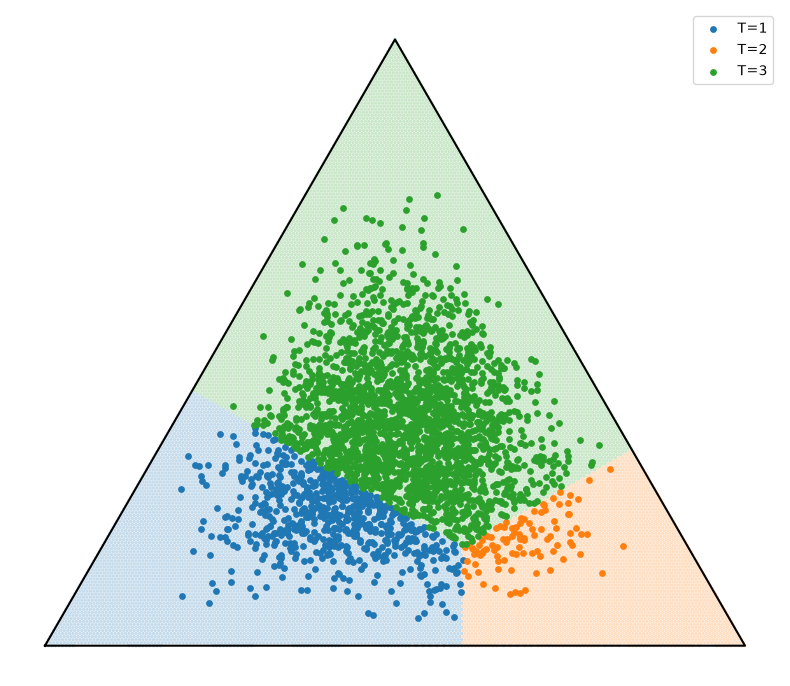

In [9]:
# Regions under the Y-optimal threshold
tau_Y = np.array(results["optimum"]["Y"]["tau"])

data_Y = data.copy()
data_Y["T"] = decision_rule(data_Y[score_cols].values, tau_Y)

plot_simplex(data_Y, tau_Y)

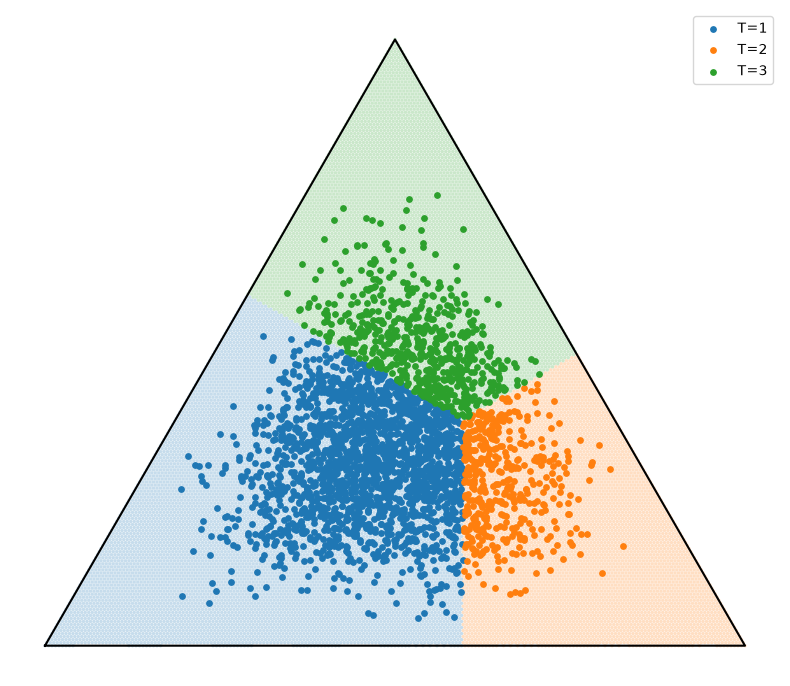

In [10]:
# Regions under the R-optimal threshold
tau_R = np.array(results["optimum"]["R"]["tau"])

data_R = data.copy()
data_R["T"] = decision_rule(data_R[score_cols].values, tau_R)

plot_simplex(data_R, tau_R)